# Customer Segmentation Analysis on Retail Purchasing Data

#### Mika Amit 14848805

## Analyzing data structure

In [1]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


&nbsp;

In [2]:
import pandas as pd
import numpy as np

df = pd.read_excel("Online_Retail.xlsx")


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


&nbsp;

#### Take aways from analyzing the data:
- Invoice Date is already in datetime
- Need to remove null customer ID values 
- Need to investigate why there is negative unit prices 
- Since Invoice No did not come in the stats meant there were alpha objects(research and saw these were cancellations)

&nbsp;

## Data cleaning 

In [6]:
# Remove values missing customer data 
df_nonull = df[df["CustomerID"].notna()]
df_nonull.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


In [7]:
# Remove cancelled orders
df_nocancel = df_nonull[~df_nonull['InvoiceNo'].astype(str).str.startswith('C')]
df_nocancel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      397924 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


&nbsp;

##### Observations
Negative quantities and unit prices are due to returns made by customers. Best practice looking at my research question would be to remove these values. This is as I am trying to model consumer purchasing patterns and not customer satisfaction or product quality. While these aspects may have possible mediator effects they would potentialy obcure results.

In [8]:
# Removes negative unit prices and quantities
df_final = df_nocancel[(df_nocancel['Quantity'] > 0) & (df_nocancel['UnitPrice'] > 0)].copy()

df_final.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,397884.000000,397884,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,179.331775,NaN,22.097877,1713.141560


&nbsp;

## Feature Engineering:
1. Recency (days since purchase)
2. Frequency (how often does a customer purchase counted in no. of orders)
3. Monetary value (how much has each customer bought in ttl)
4. Average order value (for each customer)
5. Number of unique products purchased (per customer)


### Recency

In [9]:
# Creating the recency feature 
last_order_date = df_final["InvoiceDate"].max()

# Finds the most recent order for each customer 
customer_recent_order = df_final.groupby("CustomerID")["InvoiceDate"].max()

# Compares purchase to most recent order date 
customer_recency = last_order_date - customer_recent_order

# Use dt.days to be able to access the days in the timedelta dtype 
customer_recency_days = customer_recency.dt.days

customer_recency_days



CustomerID
12346.0    325
12347.0      1
12348.0     74
12349.0     18
12350.0    309
          ... 
18280.0    277
18281.0    180
18282.0      7
18283.0      3
18287.0     42
Name: InvoiceDate, Length: 4338, dtype: int64

### Frequency

In [10]:
# Frequency 
frequency_counts = df_final.groupby("CustomerID")["InvoiceNo"].nunique()
frequency_counts

CustomerID
12346.0     1
12347.0     7
12348.0     4
12349.0     1
12350.0     1
           ..
18280.0     1
18281.0     1
18282.0     2
18283.0    16
18287.0     3
Name: InvoiceNo, Length: 4338, dtype: int64

### Monetary value





In [11]:
# Need to create a total price column 
df_final["TotalOrderPrice"] = df_final["Quantity"] * df_final["UnitPrice"]

df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   InvoiceNo        397884 non-null  object        
 1   StockCode        397884 non-null  object        
 2   Description      397884 non-null  object        
 3   Quantity         397884 non-null  int64         
 4   InvoiceDate      397884 non-null  datetime64[ns]
 5   UnitPrice        397884 non-null  float64       
 6   CustomerID       397884 non-null  float64       
 7   Country          397884 non-null  object        
 8   TotalOrderPrice  397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


In [12]:
# Monetary value per customer 
monetary_value= df_final.groupby("CustomerID")["TotalOrderPrice"].sum()

monetary_value

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
             ...   
18280.0      180.60
18281.0       80.82
18282.0      178.05
18283.0     2094.88
18287.0     1837.28
Name: TotalOrderPrice, Length: 4338, dtype: float64

### Average Order Value

In [13]:
avg_order_value = df_final.groupby("CustomerID")["TotalOrderPrice"].mean()

avg_order_value


CustomerID
12346.0    77183.600000
12347.0       23.681319
12348.0       57.975484
12349.0       24.076027
12350.0       19.670588
               ...     
18280.0       18.060000
18281.0       11.545714
18282.0       14.837500
18283.0        2.771005
18287.0       26.246857
Name: TotalOrderPrice, Length: 4338, dtype: float64

In [14]:
# Number of unique items 
unique_items = df_final.groupby("CustomerID")["StockCode"].nunique()

unique_items

CustomerID
12346.0      1
12347.0    103
12348.0     22
12349.0     73
12350.0     17
          ... 
18280.0     10
18281.0      7
18282.0     12
18283.0    263
18287.0     59
Name: StockCode, Length: 4338, dtype: int64


#### Observations
Looking at these previous features, all of them are static. They do a poor job representing the dynamic nature of customer behaviours. Having temporal features will allow me to do a more in depth analysis to provide potential companies with information on how to reach certain customer groups based on their activity. 


## Temporal Feature Engeineering


The features that I will be creating are :

1. Exponentially Moving Weighted Average Spend (EMWASpend)
2. Purchase Irregularity 
3. Spend Momentum 
4. Repeat Purchase Ratio

In [15]:
# Order data to be able to do temporal features 
df_final = df_final.sort_values(["CustomerID", "InvoiceDate"])

All current data is done on the product level. Meaning that if a customer checks out with multiple items it will be recorded as multiple seperate orders. This could distort the cluster behaviour analysis later on. Hence the data needs to be on the purchase level.

In [16]:
# Agregatting all invoices with same customer ID and order ID  
# Picks first row date, sum of the whole order, and sum of quantities 

invoice_level = df_final.groupby(["CustomerID", "InvoiceNo"]).agg(
    InvoiceDate=("InvoiceDate", "first"),
    InvoiceValue=("TotalOrderPrice", "sum"),
    BasketQuantity=("Quantity", "sum")
).reset_index()

invoice_level = invoice_level.sort_values(["CustomerID", "InvoiceDate"])

invoice_level.shape



(18532, 5)

&nbsp;

### EMWA Spend

I will use the method of Expontatially Moving Weighted Average, a method taken from many sports modelling approaches. This allows me with control of the alpha value to be able to adjust the weight of previous purchase history in comparison to more recent purchases. Therfore giving me information on how much is the customer spending recently on average.

I picked an alpha of 0.3 as I want to place more weight on recent information without forgetting previous transactions too quickly. This is in typically the middle threshold I observed when researching. 

In [17]:
# Takes the last value of the series to get the most recent average 
ewma_spend = invoice_level.groupby("CustomerID")["InvoiceValue"] \
                                            .apply(lambda x: x.ewm(alpha=0.3).mean().iloc[-1])

ewma_spend.name = "EWMASpend"

ewma_spend

CustomerID
12346.0    77183.600000
12347.0      609.731424
12348.0      388.699566
12349.0     1757.550000
12350.0      334.400000
               ...     
18280.0      180.600000
18281.0       80.820000
18282.0       87.051176
18283.0      182.496653
18287.0      523.557626
Name: EWMASpend, Length: 4338, dtype: float64

&nbsp;

### Purchase Irregularity

Next feature is Purchase Irregularity. This will give an indication on how consistent a customer is with their purchase based on the standard deviation, not just how recent the purchase was. A high value indicates high varability between days of purchase.  

In [18]:
# Same difference logic as the Recency feature calculation
invoice_level["DaysBetweenPurchases"] = (
    invoice_level.groupby("CustomerID")["InvoiceDate"]
    .diff()
    .dt.days
)

# Fill NAs for customer who purchased one time or for the first order value 
purchase_irregularity = (
    invoice_level.groupby("CustomerID")["DaysBetweenPurchases"]
    .std()
    .fillna(0)
    .rename("PurchaseIrregularity")
)

purchase_irregularity

CustomerID
12346.0     0.000000
12347.0    18.478817
12348.0    70.149840
12349.0     0.000000
12350.0     0.000000
             ...    
18280.0     0.000000
18281.0     0.000000
18282.0     0.000000
18283.0    18.563405
18287.0    89.802561
Name: PurchaseIrregularity, Length: 4338, dtype: float64

&nbsp;

### Spend Momentum

The next feature is Spend Momentum. This will take the most recent average and the most historic average of spending and will see if over time each customer's spending has increased or decreased. This can indicate behavioural traits like customer satisfaction and loyalty. 

If Spend Momentum is positive there is a higher spending trend observed recently for the customer.

In [19]:
def spend_momentum(x):
    if len(x) < 2:
        return 0
    
    middle = len(x) // 2
    
    older_avg = x.iloc[:middle].mean()
    recent_avg = x.iloc[middle:].mean()
    
    return recent_avg - older_avg

spend_momentum_feature = (
    invoice_level.groupby("CustomerID")["InvoiceValue"]
    .apply(spend_momentum)
    .rename("SpendMomentum")
)

spend_momentum_feature.head()

CustomerID
12346.0      0.0000
12347.0     13.8325
12348.0   -221.6200
12349.0      0.0000
12350.0      0.0000
Name: SpendMomentum, dtype: float64

&nbsp;

### Repeat Purchase Ratio

The last feature is Repeat Purchase Ratio. Looking at the Uniquness feature above I realised that while it shows the sum of all the unique products purchased it doesnt combine the amount of times that a customer rebought the same product. This would be useful to see customer loyaly and satisfaction to the retailers product. 

A high value indicates that out of all purchases most were repeat purchases of products.

In [20]:
# Done on full data set and not on invoice level as need to look at all orders
repeat_purchase_ratio = (
    df_final.groupby("CustomerID")["StockCode"]
    .apply(lambda x: x.duplicated().mean())
    .rename("RepeatPurchaseRatio")
)

repeat_purchase_ratio.head()

CustomerID
12346.0    0.000000
12347.0    0.434066
12348.0    0.290323
12349.0    0.000000
12350.0    0.000000
Name: RepeatPurchaseRatio, dtype: float64

&nbsp;

In [21]:
# Combining into one feauture engineered table 
df_features = pd.DataFrame({
    "Recency": customer_recency_days,
    "Frequency": frequency_counts,
    "MonetaryValue": monetary_value,
    "AverageOrderValue": avg_order_value,
    "UniqueItems": unique_items,
    "EWMASpend": ewma_spend,
    "PurchaseIrregularity": purchase_irregularity,
    "SpendMomentum": spend_momentum_feature,
    "RepeatPurchaseRatio": repeat_purchase_ratio
}).fillna(0)

df_features.describe()

,Recency,Frequency,MonetaryValue,AverageOrderValue,UniqueItems,EWMASpend,PurchaseIrregularity,SpendMomentum,RepeatPurchaseRatio
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2054.266460,68.350506,61.501153,419.820617,19.190723,18.369098,0.149983
std,100.014169,7.697998,8989.230441,1467.918896,85.366768,1963.309437,31.862067,2593.771756,0.175368
min,0.000000,1.000000,3.750000,2.101286,1.000000,3.017647,0.000000,-8818.260000,0.000000
25%,17.000000,1.000000,307.415000,12.365367,16.000000,175.927545,0.000000,-46.772333,0.000000
50%,50.000000,2.000000,674.485000,17.723119,35.000000,290.378410,0.000000,0.000000,0.090909
75%,141.000000,5.000000,1661.740000,24.858417,77.000000,426.224265,28.362975,22.539226,0.240000
max,373.000000,209.000000,280206.020000,77183.600000,1787.000000,99100.958824,242.537626,168466.700000,0.929293


&nbsp;

## Standardization of data 


Next to be able to continue modelling I need to scale my data. K-means is based on euclidien distance hence any high value, in this instance especially monetary values will dominate the variablilty and therefore I need to normalize all the data values.

I picked standardization as I wanted the data to be less sensitive to outliers and I thought having the data be normally distrubuted might help my interpretations of clustering results 

In [22]:
import sklearn 
from sklearn import preprocessing

scaler = preprocessing.StandardScaler().fit(df_features)

features_scaled = scaler.transform(df_features)
features_scaled


array([[ 2.33457414e+00, -4.25096503e-01,  8.35866818e+00, ...,
        -6.02375716e-01, -7.08281904e-03, -8.55343752e-01],
       [-9.05340320e-01,  3.54416797e-01,  2.50966264e-01, ...,
        -2.23459633e-02, -1.74923694e-03,  1.62010659e+00],
       [-1.75359593e-01, -3.53398530e-02, -2.85960063e-02, ...,
         1.59955067e+00, -9.25358077e-02,  8.00347411e-01],
       ...,
       [-8.45341904e-01, -2.95177619e-01, -2.08742313e-01, ...,
        -6.02375716e-01, -1.57083193e-02, -8.55343752e-01],
       [-8.85340848e-01,  1.52368675e+00,  4.51854273e-03, ...,
        -1.96908339e-02, -8.97097667e-04,  2.86363450e+00],
       [-4.95351144e-01, -1.65258736e-01, -2.41412739e-02, ...,
         2.21642801e+00, -9.54893764e-02,  4.08319410e-02]])

In [23]:
# Output is in array and lost column names 
# Need to convert it back to df

df_scaled = pd.DataFrame(features_scaled, 
                         columns=df_features.columns, 
                         index=df_features.index)

df_scaled.head()

,Recency,Frequency,MonetaryValue,AverageOrderValue,UniqueItems,EWMASpend,PurchaseIrregularity,SpendMomentum,RepeatPurchaseRatio
CustomerID,,,,,,,,,
12346.0,2.334574,-0.425097,8.358668,52.539782,-0.708802,39.103682,-0.602376,-0.007083,-0.855344
12347.0,-0.905340,0.354417,0.250966,-0.030434,0.486180,0.096741,-0.022346,-0.001749,1.620107
12348.0,-0.175360,-0.035340,-0.028596,-0.007069,-0.462776,-0.015853,1.599551,-0.092536,0.800347
12349.0,-0.735345,-0.425097,-0.033012,-0.030165,0.134715,0.681443,-0.602376,-0.007083,-0.855344
12350.0,2.174578,-0.425097,-0.191347,-0.033166,-0.521354,-0.043513,-0.602376,-0.007083,-0.855344


In [24]:
# Inspect scaled feature tablle 
df_scaled.describe()

,Recency,Frequency,MonetaryValue,AverageOrderValue,UniqueItems,EWMASpend,PurchaseIrregularity,SpendMomentum,RepeatPurchaseRatio
count,4.338000e+03,4.338000e+03,4.338000e+03,4.338000e+03,4.338000e+03,4.338000e+03,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,1.801745e-17,1.801745e-17,-7.370775e-18,-1.801745e-17,-1.310360e-17,-5.241440e-17,4.913850e-18,-1.216178e-16
std,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-4.250965e-01,-2.281344e-01,-4.513659e-02,-7.088019e-01,-2.123206e-01,-6.023757e-01,-3.407257e+00,-8.553438e-01
25%,-7.453445e-01,-4.250965e-01,-1.943495e-01,-3.814352e-02,-5.330692e-01,-1.242398e-01,-6.023757e-01,-2.511745e-02,-8.553438e-01
50%,-4.153533e-01,-2.951776e-01,-1.535104e-01,-3.449320e-02,-3.104745e-01,-6.593822e-02,-6.023757e-01,-7.082819e-03,-3.368950e-01
75%,4.946227e-01,9.457903e-02,-4.367134e-02,-2.963182e-02,1.815769e-01,3.262036e-03,2.879069e-01,1.607932e-03,5.133609e-01
max,2.814561e+00,2.659803e+01,3.094634e+01,5.253978e+01,2.021510e+01,5.026845e+01,7.010614e+00,6.495088e+01,4.444355e+00


&nbsp;

## Modelling 1

An elbow plot was constructed to be able to see within distance in each cluster to see at what point was the inertia reaching a more stable flat point which would determine the cluster value for k-means.

Text(0, 0.5, 'Inertia')

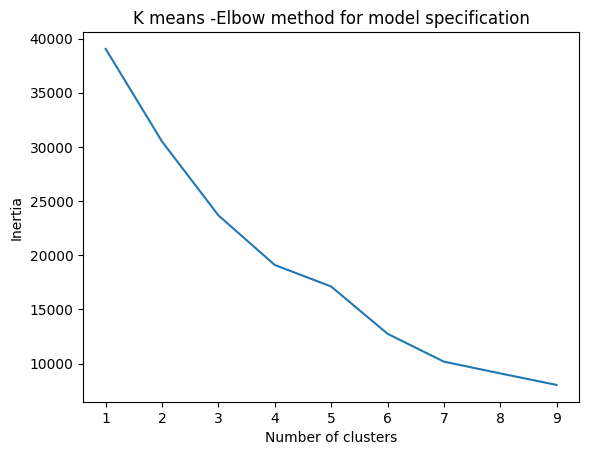

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


costs = []
k_values = range(1, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
    kmeans.fit(df_scaled)
    costs.append(kmeans.inertia_)
    
plt.plot(k_values, costs)
plt.title("K means -Elbow method for model specification")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")



&nbsp;

#### Interpretation of elbow plot
Looking at the elbow plot there is no clear indication of the number of clusters that I should pick I will do further analysis decide on the k parameter.

### Silhouette Analysis 

This analysis looks at the difference between the distance from a point in a cluster to all other points in its own cluster, and the distance between the respective point to points in other nearby clusters. A high score is good as it is indicative that the nearest clusters are far away and that points in the respective point's cluster are close together. 

The silhouette score is average for each k to see which k value gives the best fit 

In [26]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)

print(silhouette_scores)

[0.9704237287217947, 0.37254976855072114, 0.30754976031077774, 0.3100438194544268, 0.34010664008679975, 0.37952141295824865, 0.37893031044977216, 0.3810827610198647, 0.368672883138357]


&nbsp;

#### Interpretation
K=2 gives me the highest score. Unfortunately this means that I cannot analyse the consumer groups very well. I have too many dimensions in my data and not enough data to be able to properly fit the models. In this case PCA was an option, but to try and preserve feature interpretability I am going to remove excess features to cut dimensions. 


In [27]:
df_reduced = df_features[[
    "Recency",
    "Frequency",
    "MonetaryValue",
    "EWMASpend",
    "PurchaseIrregularity",
    "SpendMomentum",
    "RepeatPurchaseRatio"
]]

df_reduced.head()


,Recency,Frequency,MonetaryValue,EWMASpend,PurchaseIrregularity,SpendMomentum,RepeatPurchaseRatio
CustomerID,,,,,,,
12346.0,325,1,77183.60,77183.600000,0.000000,0.0000,0.000000
12347.0,1,7,4310.00,609.731424,18.478817,13.8325,0.434066
12348.0,74,4,1797.24,388.699566,70.149840,-221.6200,0.290323
12349.0,18,1,1757.55,1757.550000,0.000000,0.0000,0.000000
12350.0,309,1,334.40,334.400000,0.000000,0.0000,0.000000


In [28]:
scaler = preprocessing.StandardScaler().fit(df_reduced)

features_scaled = scaler.transform(df_reduced)

df_scaled_removed = pd.DataFrame(features_scaled, 
                         columns=df_reduced.columns, 
                         index=df_reduced.index)

df_scaled_removed.head()

,Recency,Frequency,MonetaryValue,EWMASpend,PurchaseIrregularity,SpendMomentum,RepeatPurchaseRatio
CustomerID,,,,,,,
12346.0,2.334574,-0.425097,8.358668,39.103682,-0.602376,-0.007083,-0.855344
12347.0,-0.905340,0.354417,0.250966,0.096741,-0.022346,-0.001749,1.620107
12348.0,-0.175360,-0.035340,-0.028596,-0.015853,1.599551,-0.092536,0.800347
12349.0,-0.735345,-0.425097,-0.033012,0.681443,-0.602376,-0.007083,-0.855344
12350.0,2.174578,-0.425097,-0.191347,-0.043513,-0.602376,-0.007083,-0.855344


I removed AverageOrderValue as I figured the moving average kind of encapsulates that information. Uniqueness while providing usefull info overlaps abit with the repeat purchase ratio, so I removed it as well.

In [29]:
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled_removed)
    
    score = silhouette_score(df_scaled_removed, labels)
    silhouette_scores.append(score)

print(silhouette_scores)

[0.9705216536699005, 0.37901479661850895, 0.36026486045539635, 0.3750312150888621, 0.37576615934737895, 0.42459420373491835, 0.40661443046136714, 0.4077897473923055, 0.4154834882640695]


As can be seen removing similair features did not change the structure of the clusters at all. While this is not the expected results I kept the data frame this way to remove redundency. 

As can be seen instead of meanigful customer segmentation I recieved two clusters that determined if a customer is simply active or not. As this overall factor accounted for most of the variation. I realised that this is beacuse of outliers in the data and needed to deal with them accordingly to be able to procced with any meaningful analysis.

In [30]:
for col in ["MonetaryValue", "EWMASpend", "SpendMomentum", "Frequency"]:
    upper = df_reduced[col].quantile(0.95)
    df_reduced = df_reduced[df_reduced[col] <= upper]

df_reduced.head()

,Recency,Frequency,MonetaryValue,EWMASpend,PurchaseIrregularity,SpendMomentum,RepeatPurchaseRatio
CustomerID,,,,,,,
12347.0,1,7,4310.00,609.731424,18.478817,13.8325,0.434066
12348.0,74,4,1797.24,388.699566,70.149840,-221.6200,0.290323
12350.0,309,1,334.40,334.400000,0.000000,0.0000,0.000000
12352.0,35,8,2506.04,300.550698,64.537918,-74.2300,0.305882
12353.0,203,1,89.00,89.000000,0.000000,0.0000,0.000000


In [31]:
df_reduced.describe()

,Recency,Frequency,MonetaryValue,EWMASpend,PurchaseIrregularity,SpendMomentum,RepeatPurchaseRatio
count,3549.000000,3549.000000,3549.000000,3549.000000,3549.000000,3549.000000,3549.000000
mean,100.140039,2.802761,831.174895,279.635102,18.481046,-45.387663,0.117623
std,102.847455,2.196000,863.899259,156.000961,32.315637,158.555110,0.141449
min,0.000000,1.000000,3.750000,3.017647,0.000000,-2001.715000,0.000000
25%,21.000000,1.000000,254.820000,160.570000,0.000000,-53.080000,0.000000
50%,58.000000,2.000000,508.810000,250.124201,0.000000,0.000000,0.068027
75%,162.000000,4.000000,1093.680000,364.373289,28.846886,0.000000,0.195122
max,373.000000,10.000000,5739.460000,797.459680,242.537626,186.240000,0.804878


&nbsp;

I have also implemented the robust scaled instead of standard. I was looking into methods of dealing with heavily skewed data and figured this would be a solution to my current problems with outliers. This method also has the bonus of being easier to interpret as it is simply below or above the median in interpreation as the median and the IQR are used to scale the data.

&nbsp;

In [32]:

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
cutoff_data = scaler.fit_transform(df_reduced)

df_cutoff_scaled = pd.DataFrame(cutoff_data, columns=df_reduced.columns, index=df_reduced.index)

df_cutoff_scaled.head()


,Recency,Frequency,MonetaryValue,EWMASpend,PurchaseIrregularity,SpendMomentum,RepeatPurchaseRatio
CustomerID,,,,,,,
12347.0,-0.404255,1.666667,4.531376,1.764482,0.640583,0.260597,1.875948
12348.0,0.113475,0.666667,1.535930,0.679947,2.431799,-4.175207,1.139264
12350.0,1.780142,-0.333333,-0.207913,0.413515,0.000000,0.000000,-0.348639
12352.0,-0.163121,2.000000,2.380886,0.247427,2.237258,-1.398455,1.219008
12353.0,1.028369,-0.333333,-0.500453,-0.790587,0.000000,0.000000,-0.348639


&nbsp;

## Modelling 2 

Repeating the same elbow plot and sillouehtte analysis methods.

In [33]:
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_cutoff_scaled)
    
    score = silhouette_score(df_cutoff_scaled, labels)
    silhouette_scores.append(score)

print(silhouette_scores)

[0.6071555906965606, 0.3635306837733258, 0.38329950821817343, 0.2271689500763267, 0.37158615880528206, 0.34519280135215263, 0.26043441726073024, 0.2610309278320741, 0.2637088866558838]


Text(0, 0.5, 'Inertia')

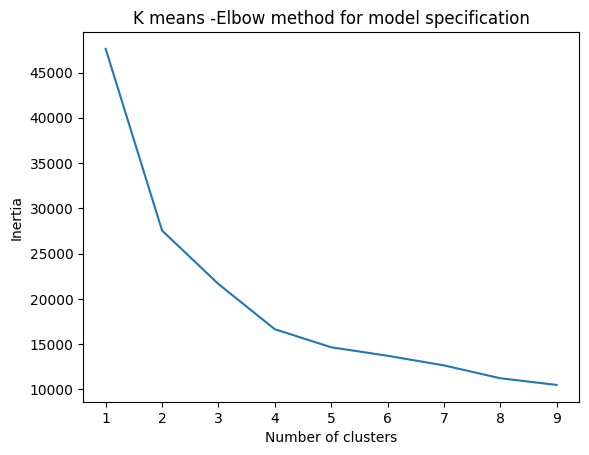

In [34]:
costs = []
k_values = range(1, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
    kmeans.fit(df_cutoff_scaled)
    costs.append(kmeans.inertia_)
    
plt.plot(k_values, costs)
plt.title("K means -Elbow method for model specification")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")

&nbsp;

### Interpretations


Based on the elbow plot the value where cost reached a plauteu visually is when k=4, no steep decline in intertia (costs) is observed beyond that point. However the silouhette analysis shows the highest values for seperation of clusters when k=2. But, this solution only provides broad interpreation segmenting customers into active vs inactive groups. K=2 is statistically optimal but not most insightful clustering structure. 

While k=4 has a lower silhouette score than k=2, it still maintains reasonable cluster separation and provides greater interpretability. Specifically, k=4 allows the identification of distinct behavioral segments, including loyalty, engagement and instability of customers.
Hence k=4 will be used for the k-means modelling. 


In [35]:
# Fit model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(df_cutoff_scaled)

# Add labels
df_cutoff_scaled["Cluster"] = kmeans.labels_

print(df_cutoff_scaled.groupby("Cluster").mean())
print(df_cutoff_scaled["Cluster"].value_counts())

          Recency  Frequency  MonetaryValue  EWMASpend  PurchaseIrregularity  \
Cluster                                                                        
0        0.546533  -0.178932      -0.187729   0.029304              0.058660   
1        0.125035   0.433333       1.640608   1.105697              0.975772   
2        0.073363   0.570175       0.960795   0.295361              0.965730   
3       -0.141909   1.137747       1.273330   0.224312              1.800343   

         SpendMomentum  RepeatPurchaseRatio  
Cluster                                      
0             0.028876            -0.102932  
1           -13.423315             0.275271  
2            -4.359619             0.501147  
3             0.458070             0.960028  
Cluster
0    2079
3     876
2     494
1     100
Name: count, dtype: int64


&nbsp;

## Interpretation of clusters 

Since values are scaled any postive values means above average and negative values are below the average customer. 

### Cluster 0 


Size: 855
- Recency = Low (bought recently)
- Frequency = High (buy often)
- Monetary Value = Very High (spend significantly above average )
- EMWA Spend = Moderate (slightly above average recent spending) 
- Purchase Irregularity = Very High (dynamic buying patterns)
- Spend Momentum = Moderate-High (spending trends increasing)
- Repeat Purchase Ratio = High (loyal to certain products)



#### Evaluation 

Customers in cluster ones are active as seen in the Recency and Frequency. Their activity is also seen in the temporal features with high values for Spend Momentum and EMWA Spend. They are also valuable to the business in terms of capital, spending a high amount on the retailors platform on average seen in Monetary Value. They are loyal to their preffered products as seen in the Repeat Purchase Ratio. These customers are also irregular in their purchases with high variability between days of orders. 

The label given to this cluster is: **High-Value Loyal Customers**.

### Cluster 1 


Size: 540
- Recency = ~0 (slightly less than average recency)
- Frequency = Moderate (frequent purchases) 
- Monetary Value = High (spend significantly above average, not as much as C0)
- EMWA Spend = Moderate (slightly above average spending recently)
- Purchase Irregularity = Moderate (quite irregular purchasing behaviour)
- Spend Momentum = Very Low (strong decline in spending trends)
- Repeat Purchase Ratio = Moderate (somewhat loyal to specific products)



#### Evaluation 

These customers show solid past loyalty to the retailor seen in significant Monetary Value spent on the platform, with moderate loyalty for their once preffered products. The temporal features allow us to gauge that this groups spending trends have been rapidly decreasing seen in the Spend Momentum. Past orders are a reason for EMWA Spend still being above average as past orders of large value are still accounted in the average, as the decay of alpha has still attached weight to these values. 

The label for this group is: **At-Risk Declining Customers**.

### Cluster 2 

Size: 2045
- Recency = High (Not active)
- Frequency = Low (Not frequently purchasing)
- Monetary Value = Low (below average spending)
- EMWA Spend = ~0 (minimal recent spending)
- Purchase Irregularity = ~0 (consistent spending pattern)
- Spend Momentum = ~0 (Stable spending trends)
- Repeat Purchase Ratio = Low (low loyalty to products)

#### Evaluation
This is the largest customer segment for the retailor. These are customers who buy infrequnty, are not active and show no real increase or decrease in recent spending patterns. They have also no strong loyalty to any particiular products. This groups spend little and do so on occassion with the consistent pattern being the inconsistency of their purchases.

The label for this group is: **Low-Engagement Low-Value Occasional Customers**. 


### Cluster 3 

Size: 109
- Recency = Moderate (slightly less recent activity than average)
- Frequency = Moderate (above average frequency)
- Monetary Value = Very High (spend significantly above average)
- EMWA Spend = High (high recent spending)
- Purchase Irregularity = High (very irregular)
- Spend Momentum = Very Very Low (sharp decline in spending)
- Repeat Purchase Ratio = Low (relatively low product loyalty)

#### Evaluation

There customers are very high revenue for the retailor seen in Monetary Value and EMWA Spend. There are very volatile and make large transactions irregularly. They do not have much loyalty to certain products and are rapidly decreasing in engangement from the platform seein in the extreme value for Spend Momentum. My assumption is that these customers are business who make large volume orders infrequently and hence are showing values way above average in Monetary Value and Spend Momentum.

The label I would give this group is: **High-Value Volatile Business Customers**.

## Visualizations 

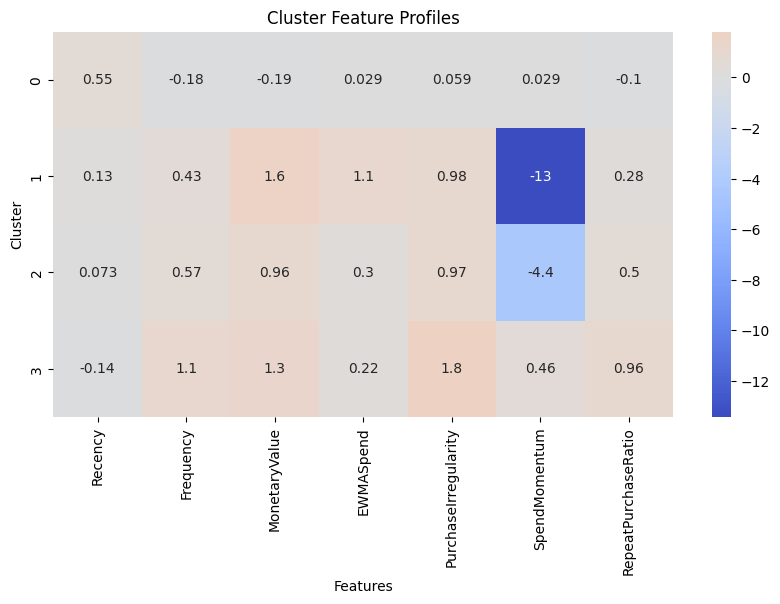

In [37]:
import seaborn as sns

# Heat map plotting
cluster_means = df_cutoff_scaled.groupby("Cluster").mean()

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_means, annot=True, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.show()

The heat map is clearly dominated by the steep drops in Spend Momentum in the declining customer bases seen in Cluster 1(At-Risk Declining Customers) and Cluster 3 (High-Value Volatile Business Customers), a clear target for marketing initiatives of declining groups they should target.

&nbsp;

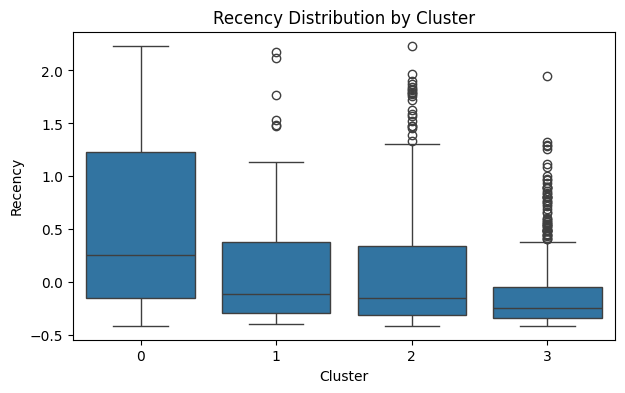

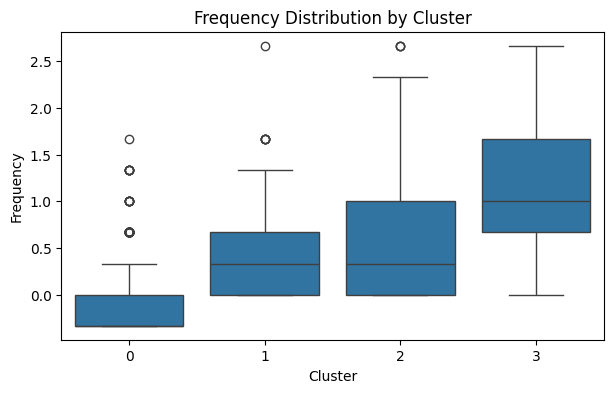

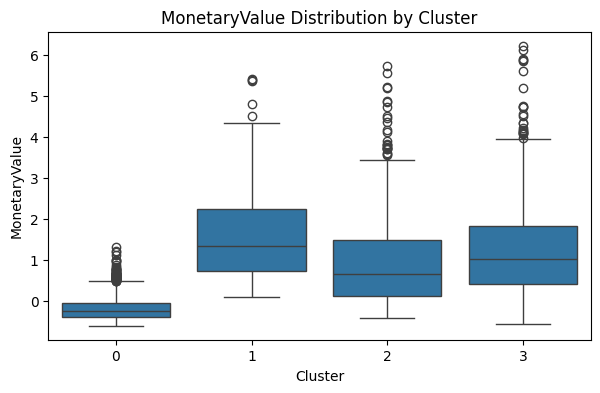

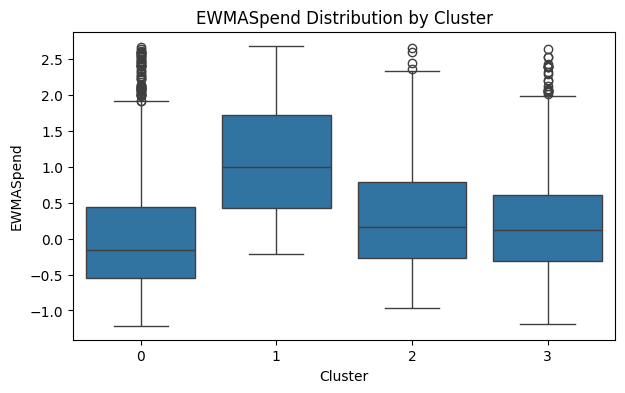

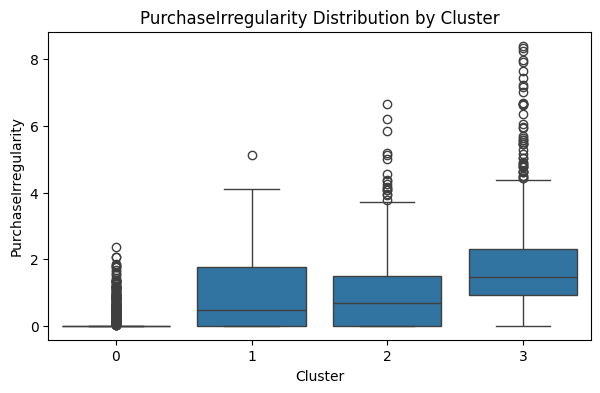

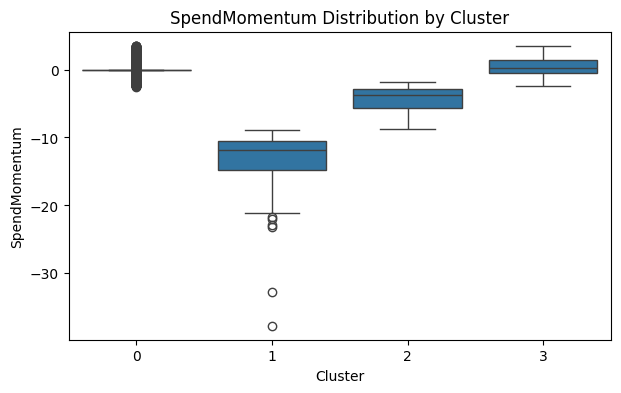

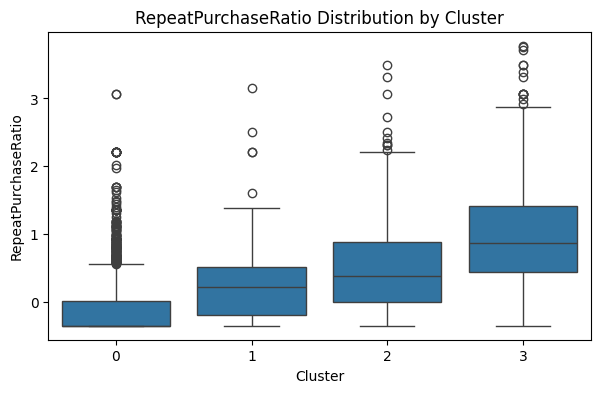

In [38]:
# Features 
features_to_plot = ["Recency", "Frequency", "MonetaryValue", "EWMASpend",\
                    "PurchaseIrregularity", "SpendMomentum", "RepeatPurchaseRatio"]
# Box plot modelling 
for feature in features_to_plot:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df_cutoff_scaled, x="Cluster", y=feature)
    plt.title(f"{feature} Distribution by Cluster")
    plt.show()

These plots hone on the same concepts descibed in the clusters above. These visualizations also show the large variability in the clusters. Many outliers are present in each feature distribution. While some are outside the IQ ranges and look like outliers its a case of underfitting, as discussed more in depth in the evaluation there was not enough data to model all clusters perfectly.

&nbsp;

## Project Evaluation

At the end my project met the goal of segmenting customers to handle the retailor's use case. This segmentation provides valuable information for the retailor to understand their customer base and to implemet future strategies to hold on to their high-value clients (Cluster 0) and target customers with declining purchasing patterns(Cluster 3 and Cluster 1). While the information learned is valuable many short comings and tenative assumptions had to be taken. Intially the data looked rich containing over 500,000 rows, once the data was cleaned and proccessed I noticed that there were only under 5,000 distinct customers to model. This means that any modelling done on the data was probably underfitted and lacked the richness to be able to diffentiate more subtle patterns of behaviour of customers besides their simple activeness. I tried too look for more data sources with more customers but the opensource ones were quite limited with the alternative being a two year data set of this same retailor. I realised this would also not solve the issue as it would only add more rows but not many more new customers. After trying various techniques to deal with the lack of information on customers and the skew of the data which emplified the effects of the latter, significant cliusters were found. The features clearly represented behavioural traits. The addition of the temporal features, which initially I though would add high of dimensionality to the data, actually made significant contributions to the interpretaion of the cluster. These features help describe patterns of behaviour rather than static statistics. Human behaviour is dynamic and with modelling I was able to capture that. 

Furthermore, as I started looking at the data more deeply I realised that the simple activeness of customers was the most determinig factor in the clusters. To combat this I used Robust Scaling and cut off large outliers in high percentiles to handle the data skew. While this allowed interpreativbility of more distinct customer behaviours it is still hanging on arbitrary cutoffs that I decided. Another limitation is the high values that were cut off were most likley the result of large business transaction as an average individual would seemigly not order almost 8,000 units of a product. The fact that CustomerID was not linked to other data tables containing adresses and names limited me in properly differenciating business transactions. Although, k-means grouped most of these asssumed business into Cluster 3.  
